In [32]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
train_file = open("data/train.csv", 'r')
train_list = train_file.readlines()
train_file.close()

In [3]:
len(train_list)

42001

In [4]:
len(train_list[0].split(","))

785

In [5]:
train_list[0]

'label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,pixel49,pixel50,pixel51,pixel52,pixel53,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,pixel64,pixel65,pixel66,pixel67,pixel68,pixel69,pixel70,pixel71,pixel72,pixel73,pixel74,pixel75,pixel76,pixel77,pixel78,pixel79,pixel80,pixel81,pixel82,pixel83,pixel84,pixel85,pixel86,pixel87,pixel88,pixel89,pixel90,pixel91,pixel92,pixel93,pixel94,pixel95,pixel96,pixel97,pixel98,pixel99,pixel100,pixel101,pixel102,pixel103,pixel104,pixel105,pixel106,pixel107,pixel108,pixel109,pixel110,pixel111,pixel112,pixel113,pixel114,pixel115,pixel116,pixel117,pixel118,pixel119,pixel120,pixel121,pixel

In [20]:
train_list[100][0]

'5'

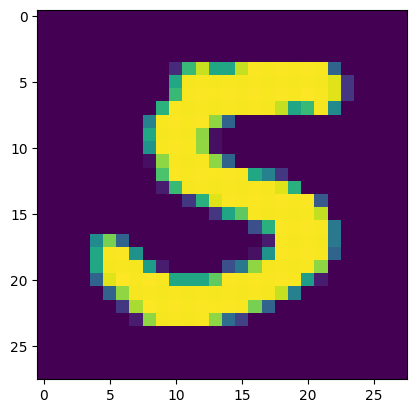

In [13]:
values = train_list[100].split(",")
image_array = np.asarray(values[1:],dtype=int).reshape((28,28))
plt.imshow(image_array)

In [14]:
scaled_input_train = (np.asarray(values[1:],dtype = float) / 255.0 * 0.99) + 0.01
print(scaled_input_train)

[0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0

In [21]:
test_file = open("data/test.csv", 'r')
test_list = test_file.readlines()
test_file.close()
print(len(test_list))

28001


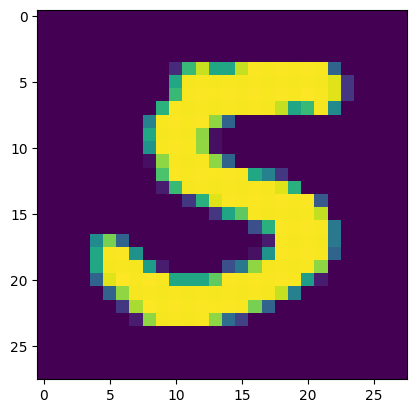

In [17]:
test_values = test_list[100].split(",")
image_array = np.asarray(values[1:],dtype=int).reshape((28,28))
plt.imshow(image_array)

In [18]:
scaled_input_test = (np.asarray(test_values[1:],dtype = float) / 255.0 * 0.99) + 0.01
print(scaled_input_test)

[0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0

In [72]:
class DNN:
    def __init__(self, sizes=[784, 128, 64, 10], epochs=10, lr=0.01):
        self.sizes = sizes
        self.epochs = epochs
        self.lr = lr

        input_layer = sizes[0]
        hidden_1 = sizes[1]
        hidden_2 = sizes[2]
        output_layer = sizes[3]

        # Xavier / He Initialization
        self.params = {
            'W1': np.random.randn(hidden_1, input_layer) * np.sqrt(2. / input_layer),
            'W2': np.random.randn(hidden_2, hidden_1) * np.sqrt(2. / hidden_1),
            'W3': np.random.randn(output_layer, hidden_2) * np.sqrt(2. / hidden_2)
        }

    def sigmoid(self, x, derivative=False):
        sig = 1 / (1 + np.exp(-np.clip(x, -500, 500)))
        if derivative:
            return sig * (1 - sig)
        return sig

    def softmax(self, x):
        exps = np.exp(x - np.max(x))
        return exps / np.sum(exps, axis=0)

    def forward_pass(self, x_train):
        params = self.params

        params['A0'] = x_train

        params['Z1'] = np.dot(params["W1"], params['A0'])
        params['A1'] = self.sigmoid(params['Z1'])

        params['Z2'] = np.dot(params["W2"], params['A1'])
        params['A2'] = self.sigmoid(params['Z2'])

        params['Z3'] = np.dot(params["W3"], params['A2'])
        params['A3'] = self.softmax(params['Z3'])

        return params['A3']

    def backward_pass(self, y_train, output):
        params = self.params
        change_w = {}

        # Gradient for Softmax with Cross-Entropy Loss: (output - target)
        error = output - y_train
        change_w['W3'] = np.outer(error, params['A2'])

        # Backpropagate to Hidden Layer 2
        error = np.dot(params['W3'].T, error) * self.sigmoid(params['Z2'], derivative=True)
        change_w['W2'] = np.outer(error, params['A1'])

        # Backpropagate to Hidden Layer 1
        error = np.dot(params['W2'].T, error) * self.sigmoid(params['Z1'], derivative=True)
        change_w['W1'] = np.outer(error, params['A0'])

        return change_w

    def update_network_parameters(self, changes_to_w):
        for key, value in changes_to_w.items():
            self.params[key] -= self.lr * value

    def compute_accuracy(self, test_data, output_nodes):
        predictions = []

        for x in test_data:
            all_values = x.split(',')
            inputs = (np.asarray(all_values[1:],dtype=float) / 255.0 * 0.99) + 0.01
            targets = np.zeros(output_nodes) + 0.01
            targets[int(all_values[0])] = 0.99
            
            output = self.forward_pass(inputs)
            pred = np.argmax(output)
            predictions.append(pred == int(all_values[0]))

        return np.mean(predictions)

    def train(self, train_list, test_list, output_nodes):
        start_time = time.time()
        for iteration in range(self.epochs):
            for x in train_list:
                all_values = x.split(',')
                inputs = (np.asarray(all_values[1:], dtype = float) / 255.0 * 0.99) + 0.01
                targets = np.zeros(output_nodes) + 0.01
                targets[int(all_values[0])] = 0.99

                output = self.forward_pass(inputs)
                changes_to_w = self.backward_pass(targets, output)
                self.update_network_parameters(changes_to_w)

            accuracy = self.compute_accuracy(test_list, output_nodes)
            print('Epoch: {0}, Time Spent: {1:.2f}s, Accuracy: {2:.2f}%'.format(
                iteration + 1, time.time() - start_time, accuracy * 100
            ))

    def predict(self, test_list):
        predictions = []
        data = test_list[1:] if test_list[0].startswith('pixel') else test_list
        
        for x in data:
            all_values = x.split(',')
            inputs = (np.asarray(all_values, dtype=float) / 255.0 * 0.99) + 0.01
            output = self.forward_pass(inputs)
            predictions.append(np.argmax(output))
            
        return predictions

In [81]:
train_data = train_list[1:35000]
val_data = train_list[35000:]

dnn = DNN(sizes=[784, 128, 64, 10], epochs=20, lr=0.01)

dnn.train(train_data, val_data, 10)

Epoch: 1, Time Spent: 16.05s, Accuracy: 87.64%
Epoch: 2, Time Spent: 31.74s, Accuracy: 89.96%
Epoch: 3, Time Spent: 47.58s, Accuracy: 91.36%
Epoch: 4, Time Spent: 66.69s, Accuracy: 92.62%
Epoch: 5, Time Spent: 85.34s, Accuracy: 93.59%
Epoch: 6, Time Spent: 101.26s, Accuracy: 94.23%
Epoch: 7, Time Spent: 117.74s, Accuracy: 94.74%
Epoch: 8, Time Spent: 134.39s, Accuracy: 94.87%
Epoch: 9, Time Spent: 151.00s, Accuracy: 95.20%
Epoch: 10, Time Spent: 167.75s, Accuracy: 95.40%
Epoch: 11, Time Spent: 184.60s, Accuracy: 95.41%
Epoch: 12, Time Spent: 200.79s, Accuracy: 95.44%
Epoch: 13, Time Spent: 216.71s, Accuracy: 95.61%
Epoch: 14, Time Spent: 232.34s, Accuracy: 95.63%
Epoch: 15, Time Spent: 247.97s, Accuracy: 95.59%
Epoch: 16, Time Spent: 265.27s, Accuracy: 95.61%
Epoch: 17, Time Spent: 314.67s, Accuracy: 95.64%
Epoch: 18, Time Spent: 331.80s, Accuracy: 95.76%
Epoch: 19, Time Spent: 348.84s, Accuracy: 95.80%
Epoch: 20, Time Spent: 364.39s, Accuracy: 95.84%


In [82]:
import pandas as pd

with open("data/test.csv", 'r') as test_file:
    kaggle_test_list = test_file.readlines()
    
test_preds = dnn.predict(kaggle_test_list)

submission = pd.DataFrame({
    'ImageId': range(1, len(test_preds) + 1),
    'Label': test_preds
})

submission.to_csv('submission.csv', index=False)
print("Saved submission.csv successfully!")

Saved submission.csv successfully!
